<a href="https://colab.research.google.com/github/Otza02/satellite-img-segmentation/blob/main/notebooks/train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Otza02/satellite-img-segmentation.git
%cd satellite-img-segmentation
!pip install -e .

Cloning into 'satellite-img-segmentation'...
remote: Enumerating objects: 162, done.
remote: Counting objects: 100% (162/162), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 162 (delta 69), reused 130 (delta 48), pack-reused 0 (from 0)
Receiving objects: 100% (162/162), 1.13 MiB | 16.98 MiB/s, done.
Resolving deltas: 100% (69/69), done.
/content/satellite-img-segmentation
Obtaining file:///content/satellite-img-segmentation
  Preparing metadata (setup.py) ... done
  Running setup.py develop for satelliteSegmentation


In [1]:
%cd /content/satellite-img-segmentation
!unzip -q data/processed.zip -d data/processed

/content/satellite-img-segmentation


In [27]:
from satelliteSegmentation.config import Config
from satelliteSegmentation.dataset import load_data, SatelliteData
from satelliteSegmentation.models.unet import UNet
from satelliteSegmentation.train import train_model, run_one_epoch
from satelliteSegmentation.metrics import segmentation_metrics
from satelliteSegmentation.utils import (
    plot_confusion_matrix,
    plot_bar_metrics,
    plot_class_metrics
)
from satelliteSegmentation.tokenizer import Tokenizer

import torch
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader

In [3]:
data_train = load_data("train")
data_val = load_data("val")

100%|██████████| 5184/5184 [00:08<00:00, 596.70it/s]


Dataset cargado:
X shape = torch.Size([5184, 3, 120, 120])
Y shape = torch.Size([5184, 120, 120])


100%|██████████| 648/648 [00:00<00:00, 713.41it/s]


Dataset cargado:
X shape = torch.Size([648, 3, 120, 120])
Y shape = torch.Size([648, 120, 120])


In [4]:
conf = Config("cuda" if torch.cuda.is_available() else "cpu", epochs=50, patience=8)
conf

Config(device='cuda', batch_size=128, kernel_size=3, stride=1, in_channels=3, hidden_channels=(64, 128, 256, 512), bottleneck_channels=1024, num_classes=7, epochs=50, lr=0.0001, patience=8, min_delta=0.001, weights=None)

In [8]:
train_loader = DataLoader(
    data_train,
    batch_size=conf.batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=conf.device == "cuda",
    persistent_workers=conf.device == "cuda",
)

val_loader = DataLoader(
    data_val,
    batch_size=conf.batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=conf.device == "cuda",
    persistent_workers=conf.device == "cuda",
)

In [9]:
model = UNet(conf)
print(f"Model params: {sum([p.numel() for p in model.parameters()]):,}")

Model params: 31,043,911


In [10]:
criterion = torch.nn.CrossEntropyLoss(conf.weights)
model, history = train_model(model, train_loader, val_loader, criterion, conf)

Epoch 01/50 | train_loss=1.3081 | val_loss=1.5601 | time 00:29
Epoch 02/50 | train_loss=0.8277 | val_loss=0.6393 | time 00:28
Epoch 03/50 | train_loss=0.7189 | val_loss=0.8247 | time 00:29
Epoch 04/50 | train_loss=0.6334 | val_loss=0.5844 | time 00:31
Epoch 05/50 | train_loss=0.5782 | val_loss=0.5084 | time 00:32
Epoch 06/50 | train_loss=0.5308 | val_loss=0.5982 | time 00:31
Epoch 07/50 | train_loss=0.4993 | val_loss=0.5547 | time 00:31
Epoch 08/50 | train_loss=0.4675 | val_loss=0.4542 | time 00:32
Epoch 09/50 | train_loss=0.4383 | val_loss=0.4132 | time 00:31
Epoch 10/50 | train_loss=0.4044 | val_loss=0.4479 | time 00:31
Epoch 11/50 | train_loss=0.3744 | val_loss=0.4416 | time 00:31
Epoch 12/50 | train_loss=0.3382 | val_loss=0.4107 | time 00:32
Epoch 13/50 | train_loss=0.3441 | val_loss=0.4436 | time 00:32
Epoch 14/50 | train_loss=0.3133 | val_loss=0.3625 | time 00:32
Epoch 15/50 | train_loss=0.2858 | val_loss=0.3633 | time 00:32
Epoch 16/50 | train_loss=0.2581 | val_loss=0.3548 | tim

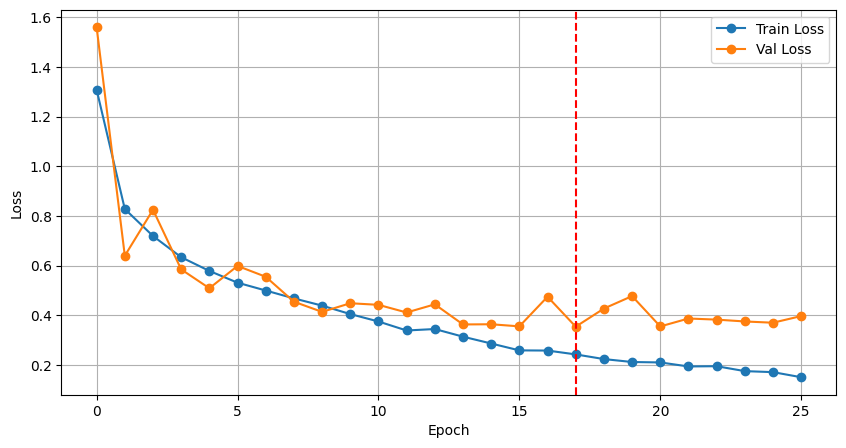

In [15]:
plt.figure(figsize=(10,5))

plt.plot(history['train_loss'], label='Train Loss', marker="o")
plt.plot(history['val_loss'], label='Val Loss', marker="o")

plt.axvline(
    history["val_loss"].index(min(history['val_loss'])),
    linestyle="--",
    color="red"
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [18]:
metrics = segmentation_metrics(model, val_loader, conf.device, conf.num_classes)
metrics.keys()

dict_keys(['dice', 'miou', 'pixel_acc', 'dice_per_class', 'iou_per_class', 'confusion_matrix'])

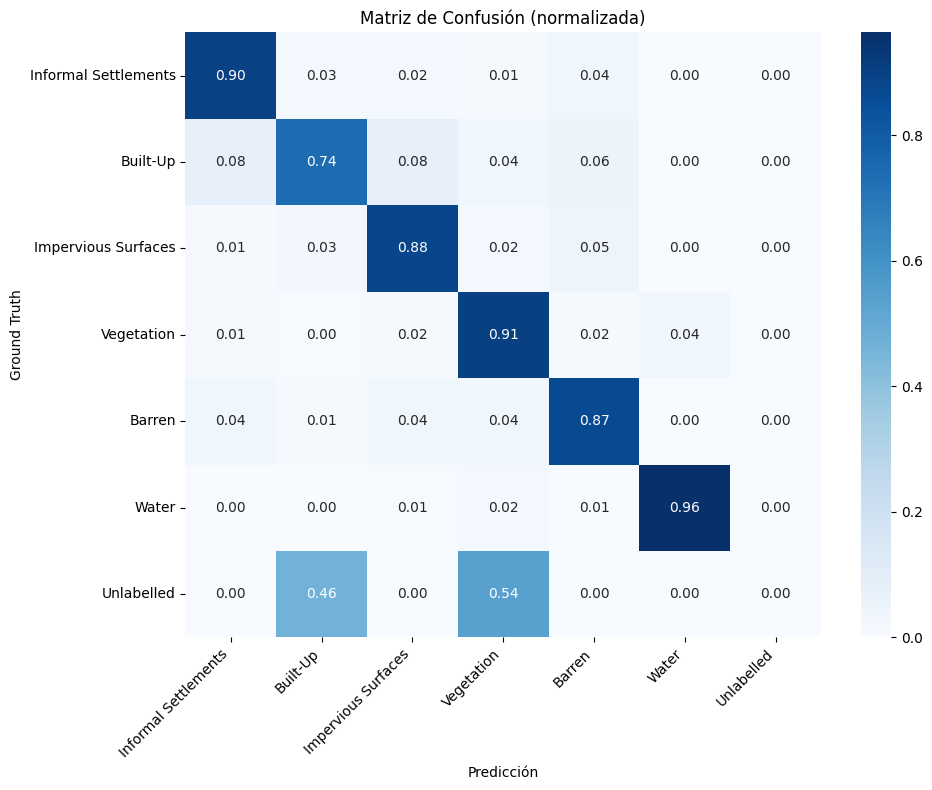

In [20]:
plot_confusion_matrix(metrics["confusion_matrix"])

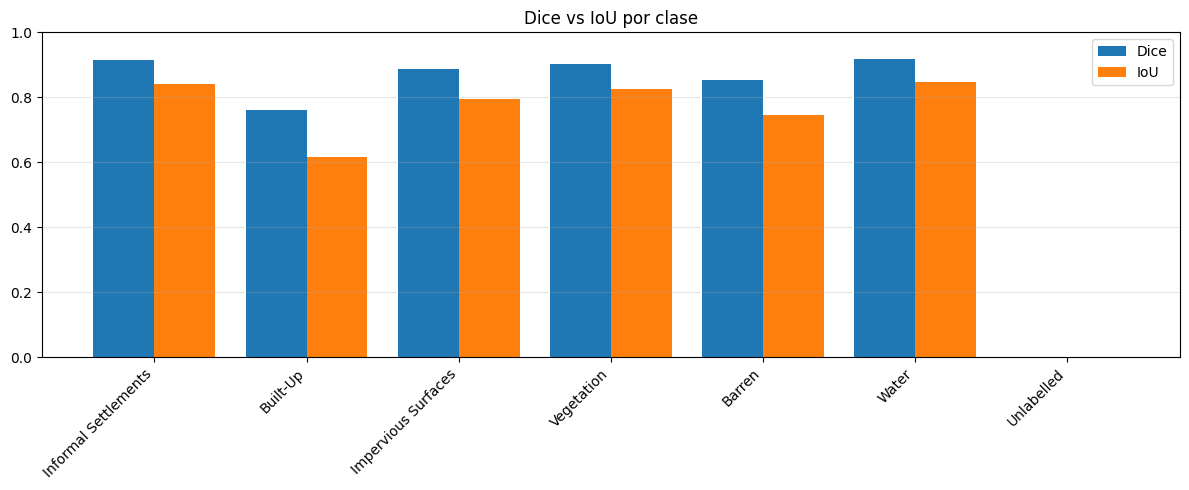

In [24]:
plot_bar_metrics(metrics["dice_per_class"], metrics["iou_per_class"])

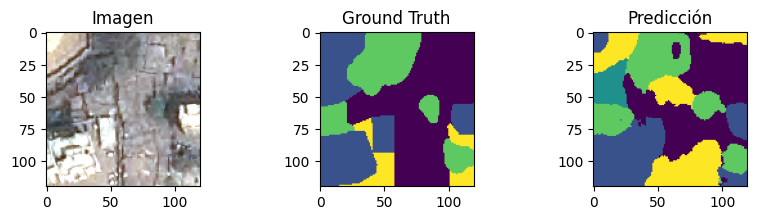

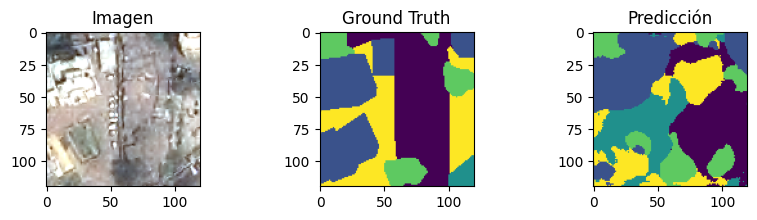

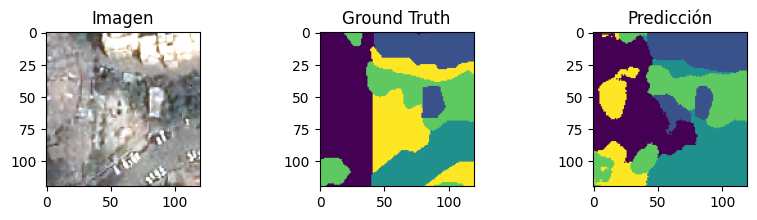

In [ ]:
@torch.inference_mode()
def plot_samples(model: torch.nn.Module, loader: DataLoader, n: int=3):
    model.eval()
    for i in range(n):
        fig, ax = plt.subplots(1,3, figsize=(10,2))

        ax[0].imshow(images[i].cpu().permute(1,2,0))
        ax[0].set_title("Imagen")
        ax[0].set_xticks([])
        ax[0].set_yticks([])

        ax[1].imshow(masks[i].cpu())
        ax[1].set_title("Ground Truth")
        ax[1].set_xticks([])
        ax[1].set_yticks([])

        ax[2].imshow(preds[i].cpu())
        ax[2].set_title("Predicción")
        ax[2].set_xticks([])
        ax[2].set_yticks([])

        plt.show()

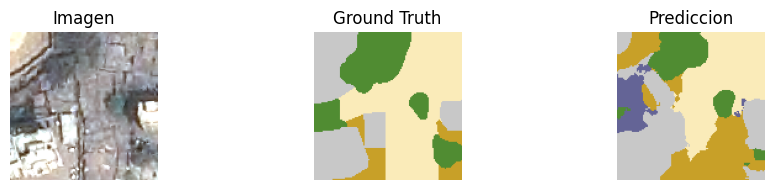

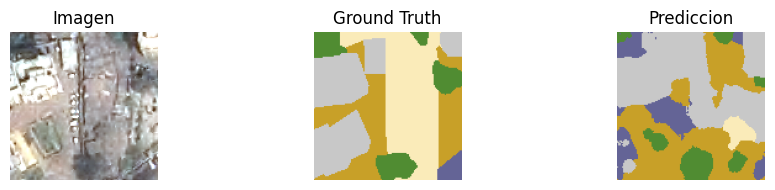

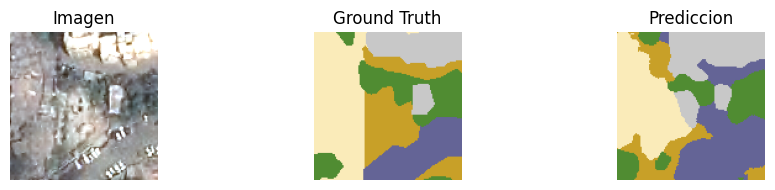

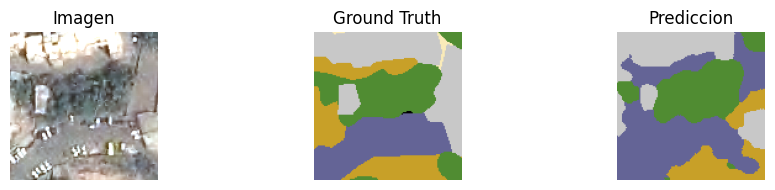

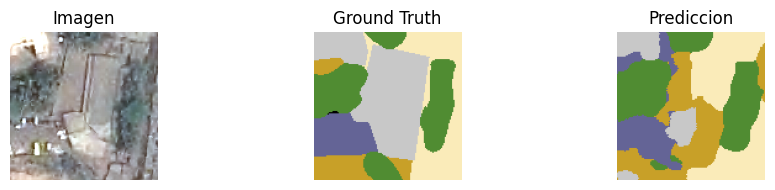

In [31]:
@torch.inference_mode()
def plot_samples(model: torch.nn.Module, loader, device: str, n: int = 3):

    model.eval()

    images, masks = next(iter(loader))

    images = images.to(device)
    masks = masks.to(device)

    logits = model(images)
    preds = torch.argmax(logits, dim=1)

    n = min(n, images.size(0))

    for i in range(n):

        fig, ax = plt.subplots(1, 3, figsize=(10, 2))

        # Imagen
        img = images[i].cpu().permute(1, 2, 0)
        ax[0].imshow(img)
        ax[0].set_title("Imagen")
        ax[0].axis("off")

        # Ground truth
        ax[1].imshow(Tokenizer.id2color(masks[i].cpu()).permute(1, 2, 0), cmap="tab10")
        ax[1].set_title("Ground Truth")
        ax[1].axis("off")

        # Pred
        ax[2].imshow(Tokenizer.id2color(preds[i].cpu()).permute(1, 2 ,0), cmap="tab10")
        ax[2].set_title("Prediccion")
        ax[2].axis("off")

        plt.tight_layout()
        plt.show()
plot_samples(model, val_loader, conf.device, 5)

In [32]:
torch.save(model.state_dict(), "baseline_2.pth")

In [33]:
metrics["dice"]

0.748102068901062

In [37]:
import pandas as pd
pd.DataFrame(history).to_csv("train.csv")